<a href="https://colab.research.google.com/github/ZenaNBamboat/schulich_data_science/blob/main/ZenaNozarBamboat_MMAI5200_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MMAI 5200 — Assignment 1  

**Student Name:** Zena Nozar Bamboat  


A small carpentry shop produces two products per day:
- **x₁** = number of wooden stools produced
- **x₂** = number of wooden benches produced

Each stool earns a profit of **dollars 8**,  and each bench earns a profit of **dollars 6**.

The shop is constrained by three limited resources per day:
- **Labor:** at most 100 hours  
- **Wood:** at most 50 boards  
- **Finishing time:** at most 60 hours  

The resource usage per unit is:
- Stool: 7 labor hours, 2 boards of wood, 4 finishing hours  
- Bench: 1 labor hour, 3 boards of wood, 1 finishing hour  

The goal is to determine how many stools and benches should be produced each day
to **maximize total profit**, allowing fractional production and requiring
non-negative quantities.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Decision variable range for plotting
x1 = np.linspace(0, 20, 400)  # stools

# Constraint lines written as x2 <=
x2_labor = 100 - 7*x1          # 7x1 + x2 <= 100
x2_wood  = (50 - 2*x1) / 3     # 2x1 + 3x2 <= 50
x2_finish = 60 - 4*x1          # 4x1 + x2 <= 60

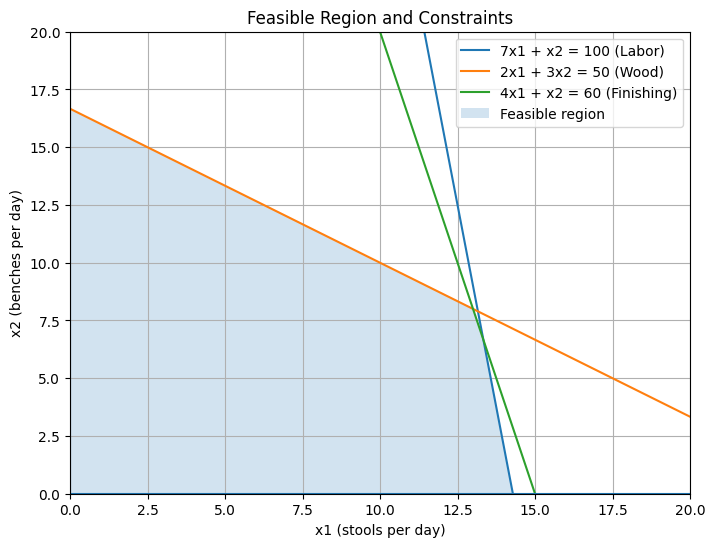

In [3]:
plt.figure(figsize=(8, 6))

# Plot constraint boundaries
plt.plot(x1, x2_labor, label="7x1 + x2 = 100 (Labor)")
plt.plot(x1, x2_wood, label="2x1 + 3x2 = 50 (Wood)")
plt.plot(x1, x2_finish, label="4x1 + x2 = 60 (Finishing)")

# Non-negativity
plt.axhline(0)
plt.axvline(0)

# Feasible region: x2 between 0 and min(all upper bounds)
x2_upper = np.minimum(np.minimum(x2_labor, x2_wood), x2_finish)
x2_upper = np.maximum(x2_upper, 0)

plt.fill_between(x1, 0, x2_upper, alpha=0.2, label="Feasible region")

plt.xlim(0, 20)
plt.ylim(0, 20)
plt.xlabel("x1 (stools per day)")
plt.ylabel("x2 (benches per day)")
plt.title("Feasible Region and Constraints")
plt.legend()
plt.grid(True)
plt.show()

The figure above shows the three constraint lines along with the shaded feasible
region. Each line represents a resource limitation: labor, wood, and finishing
time. The feasible region consists of all combinations of \(x1\) (stools) and
\(x2\) (benches) that satisfy all constraints simultaneously, along with the
non-negativity conditions.

Any point inside the shaded area represents a feasible production plan. The
boundary lines indicate where one or more resources are fully utilized, and the
corner points of the feasible region are the key candidates for the optimal
solution.

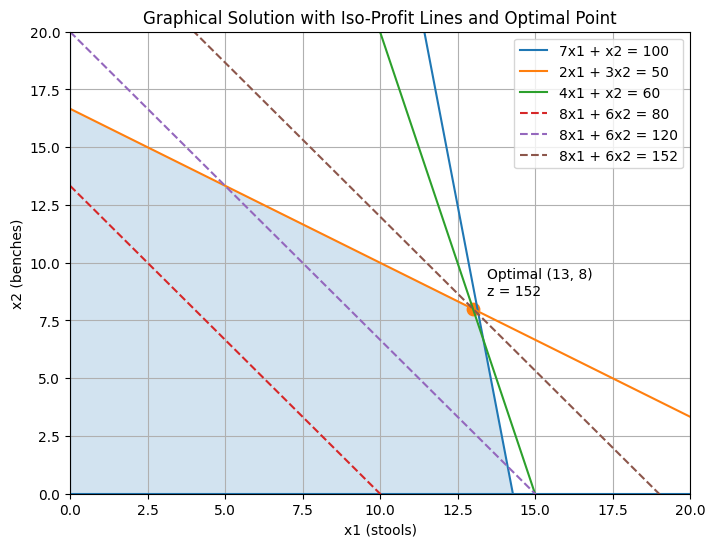

In [4]:
# Optimal point from simplex / solver
x1_star, x2_star = 13, 8
z_star = 8*x1_star + 6*x2_star

plt.figure(figsize=(8, 6))

plt.plot(x1, x2_labor, label="7x1 + x2 = 100")
plt.plot(x1, x2_wood, label="2x1 + 3x2 = 50")
plt.plot(x1, x2_finish, label="4x1 + x2 = 60")
plt.axhline(0)
plt.axvline(0)

x2_upper = np.minimum(np.minimum(x2_labor, x2_wood), x2_finish)
x2_upper = np.maximum(x2_upper, 0)
plt.fill_between(x1, 0, x2_upper, alpha=0.2)

# Iso-profit lines: 8x1 + 6x2 = k  -> x2 = (k - 8x1)/6
k_values = [80, 120, 152]  # last one touches optimum
for k in k_values:
    x2_obj = (k - 8*x1) / 6
    plt.plot(x1, x2_obj, linestyle="--", label=f"8x1 + 6x2 = {k}")

# Highlight optimum
plt.scatter([x1_star], [x2_star], s=80)
plt.annotate(f"Optimal (13, 8)\nz = {z_star}", (x1_star, x2_star),
             textcoords="offset points", xytext=(10, 10))

plt.xlim(0, 20)
plt.ylim(0, 20)
plt.xlabel("x1 (stools)")
plt.ylabel("x2 (benches)")
plt.title("Graphical Solution with Iso-Profit Lines and Optimal Point")
plt.legend()
plt.grid(True)
plt.show()

From the plot, the feasible region is shown by the shaded area. The objective
function  
\[
z = 8x1 + 6x2
\]
is represented using a set of parallel iso-profit lines.

As the profit increases, these iso-profit lines move outward in the northeast
direction. The optimal solution is found at the point where the highest
iso-profit line still touches the feasible region.

This happens at the corner point  
\[
(x1, x2) = (13, 8),
\]
which gives a maximum profit of  
\[
z = 152
\]


In [5]:
!pip -q install pulp

import pulp as pl


In [14]:
# OR solver (PuLP)
# The model (maximize)
model = pl.LpProblem("Carpentry_Shop_LP", pl.LpMaximize)

# Decision variables (non-negative, continuous)
x1 = pl.LpVariable("x1_stools", lowBound=0, cat="Continuous")
x2 = pl.LpVariable("x2_benches", lowBound=0, cat="Continuous")

# Objective function: maximize profit
model += 8*x1 + 6*x2, "Total_Profit"

# Constraints
model += 7*x1 + 1*x2 <= 100, "Labor"
model += 2*x1 + 3*x2 <= 50,  "Wood"
model += 4*x1 + 1*x2 <= 60,  "Finishing"

# Solve
model.solve(pl.PULP_CBC_CMD(msg=False))

print("Status:", pl.LpStatus[model.status])
print("x1 (stools)  =", x1.value())
print("x2 (benches) =", x2.value())
print("Max profit z =", pl.value(model.objective))

# Check of constraint usage
print("\nConstraint usage at the optimal:")
print("Labor    :", 7*x1.value() + 1*x2.value(), "<= 100")
print("Wood     :", 2*x1.value() + 3*x2.value(), "<= 50")
print("Finishing:", 4*x1.value() + 1*x2.value(), "<= 60")


Status: Optimal
x1 (stools)  = 13.0
x2 (benches) = 8.0
Max profit z = 152.0

Constraint usage at the optimal:
Labor    : 99.0 <= 100
Wood     : 50.0 <= 50
Finishing: 60.0 <= 60


In [15]:
x1_excel, x2_excel, z_excel = 13, 8, 152

x1_py = x1.value()
x2_py = x2.value()
z_py = pl.value(model.objective)
# verifying with Excel ERO results
print("Verified matches Excel x1:", abs(x1_py - x1_excel) < 1e-9)
print("Verified matches Excel x2:", abs(x2_py - x2_excel) < 1e-9)
print("Verified matches Excel z :", abs(z_py - z_excel) < 1e-9)

Verified matches Excel x1: True
Verified matches Excel x2: True
Verified matches Excel z : True


The OR solver returns  
\[
x1 = 13, x2 = 8, z = 152,
\]
which is consistent with the results obtained from both the simplex method and
Excel Solver. Seeing the same solution across all three approaches gives
confidence that the optimal solution has been correctly identified.


## Conclusion

Using both graphical analysis and an OR solver, the optimal production plan
for the carpentry shop is to produce 13 stools and 8 benches per day,
resulting in a maximum profit of $152.

Both methods yield identical results, demonstrating consistency across
analytical and computational approaches to linear programming.
